In [34]:
import os
import json
import networkx as nx
import matplotlib.pyplot as plt

In [35]:
files = "./logs-backup-20250806-194653"

In [36]:
def create_node_graph_dict(directory):
    node_id_to_name = {}
    node_graph = {}
    node_cnt = 0
    for filename in os.listdir(directory):
        filepath = os.path.join(directory, filename)
        if not os.path.isfile(filepath):
            continue
        with open(filepath, 'r', encoding='utf-8') as f:
            for line in f:
                if 'List of neighbors' in line:
                    d = json.loads(line)
                    node_graph[d['node_id']] = d.get('neighbors', [])
                    if d['node_id'] not in node_id_to_name:
                        node_id_to_name[d['node_id']] = f"node_{node_cnt}"
                        node_cnt += 1

    return node_id_to_name, node_graph

In [37]:
def build_directed_graph(node_names, graph):
    """
    Scans all files in `directory`, extracts nodes and neighbors, and builds a NetworkX DiGraph.
    """

    G = nx.DiGraph()

    for node, neighbors in graph.items():
        node_name = node_names[node]  
        G.add_node(node_name)
        for nbr in neighbors:
            if nbr in node_names:
                nbr_name = node_names[nbr]
            else:
                nbr_name = nbr
            G.add_node(nbr_name)
            G.add_edge(node_name, nbr_name)

    return G

In [38]:
def visualize_directed_graph(G, figsize=(12, 12), with_labels=True):
    # Project to undirected for consistent layout
    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=figsize)

    # Separate edges by reciprocity
    solid_edges = []  # bidirectional
    dashed_edges = []  # one-way
    for u, v in G.edges():
        if G.has_edge(v, u):
            # ensure each is drawn only once
            if (v, u) not in solid_edges:
                solid_edges.append((u, v))
        else:
            dashed_edges.append((u, v))

    # Draw nodes and labels
    nx.draw_networkx_nodes(G, pos, node_size=300)
    if with_labels:
        nx.draw_networkx_labels(G, pos)

    # Draw bidirectional edges as solid undirected
    if solid_edges:
        nx.draw_networkx_edges(
            G.to_undirected(), pos,
            edgelist=solid_edges,
            style='solid',
            arrows=False
        )
    # Draw one-way edges as dashed with arrows
    if dashed_edges:
        nx.draw_networkx_edges(
            G, pos,
            edgelist=dashed_edges,
            style='dashed',
            arrows=True
        )

    plt.title("Directed Neighbor Graph (one-way edges dashed)")
    plt.axis('off')
    plt.show()

In [39]:
nodes, graph = create_node_graph_dict(files)

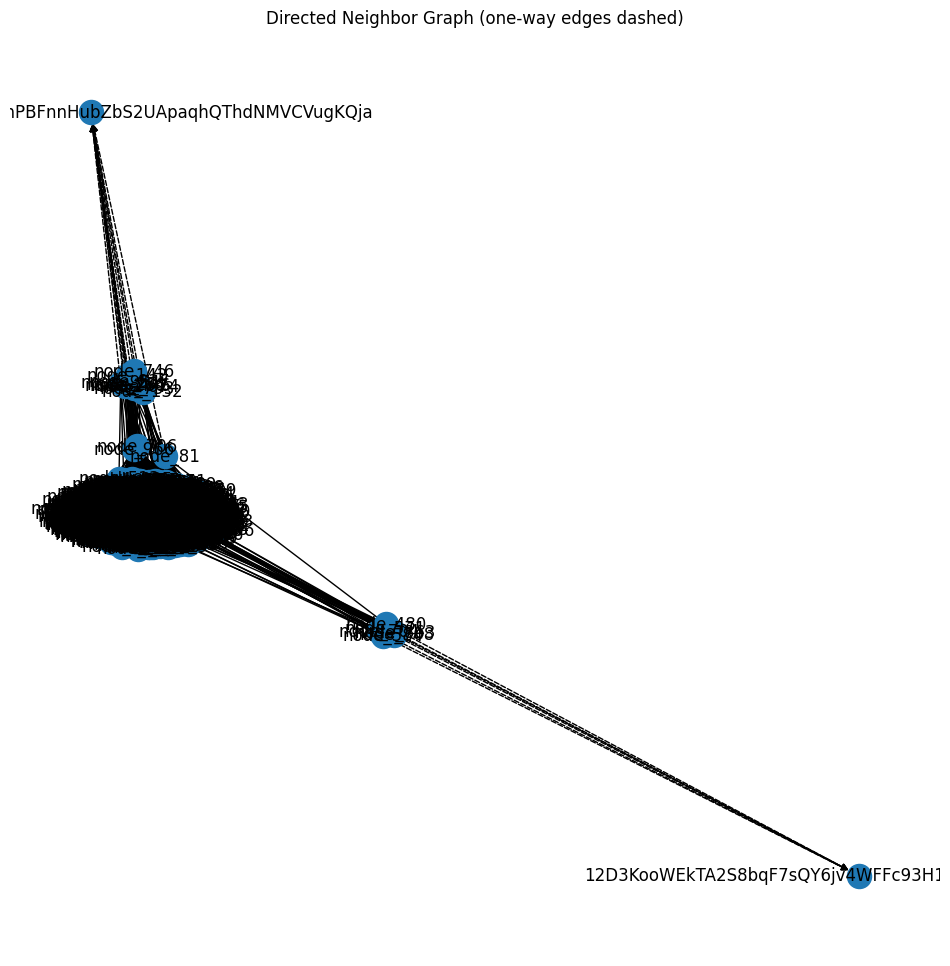

Number of connected components: 1
Component 1 (size 1000): {'node_824', 'node_522', 'node_220', 'node_721', 'node_182', 'node_88', 'node_507', 'node_577', 'node_3', 'node_373', 'node_448', 'node_515', 'node_810', 'node_256', 'node_279', 'node_669', 'node_5', 'node_528', 'node_542', 'node_870', 'node_514', 'node_275', 'node_317', 'node_160', 'node_63', 'node_239', 'node_647', 'node_501', 'node_187', 'node_911', 'node_919', 'node_453', 'node_370', 'node_73', 'node_834', 'node_938', 'node_884', 'node_792', 'node_128', 'node_255', 'node_240', 'node_670', 'node_657', 'node_297', 'node_872', 'node_300', 'node_396', 'node_705', 'node_221', 'node_614', 'node_763', 'node_722', 'node_496', 'node_844', 'node_787', 'node_991', 'node_446', 'node_16', 'node_319', 'node_512', 'node_852', 'node_225', 'node_325', 'node_199', 'node_156', 'node_75', 'node_193', 'node_588', 'node_749', 'node_666', 'node_881', 'node_371', 'node_295', 'node_754', 'node_335', 'node_920', 'node_161', 'node_682', 'node_442', '

In [40]:
nodes, graph = create_node_graph_dict(files)
G = build_directed_graph(nodes, graph)

# Visualize directed graph
visualize_directed_graph(G)

# Analyze undirected projection for components and diameter
U = G.to_undirected()
comps = list(nx.connected_components(U))
print(f"Number of connected components: {len(comps)}")
for i, comp in enumerate(comps, 1):
    print(f"Component {i} (size {len(comp)}): {comp}")

for i, comp in enumerate(comps, 1):
    if len(comp) > 1:
        subU = U.subgraph(comp)
        diam = nx.diameter(subU)
        print(f"Diameter of component {i}: {diam}")
    else:
        print(f"Component {i} has a single node; diameter undefined.")

In [41]:
def analyze_committee(directory):
    all_committees = {}
    for filename in os.listdir(directory):
        filepath = os.path.join(directory, filename)
        if not os.path.isfile(filepath):
            continue
        with open(filepath, 'r', encoding='utf-8') as f:
            for line in f:
                if "Committee elected" in line:
                    d = json.loads(line)
                    node_id = d["node_id"]  
                    committee = d["committee"]
                    all_committees[node_id] = [id["ID"] for id in committee]
    return all_committees

In [42]:
member_to_nodes = analyze_committee(files)

In [43]:
committee = set()
minimal_committee = 200
for k, v in member_to_nodes.items():
    print(k, len(v))
    minimal_committee = min(minimal_committee, len(v))
    for c in v:
        committee.add(c)

print(len(committee))
print(minimal_committee)

12D3KooWQ7seknHSBgGgQuSnyvWfodRakaTgBUPGZ1dXBp4R6Yhj 12
12D3KooWFMwmYrKA9q4io2PFGqxdz7wrvRxBANZJiXEtcQiSbFSo 12
12D3KooWNrUx1r1wbzmtaxZzHxfgcwKVKStb5qNrBuothLRxmaG2 12
12D3KooWRbor34vnSuu2mthbMUiFKCXnL5D7q5ZUYVbpAKLt4u6s 12
12D3KooWPCUdbND7jUUkTLTJpG4HC8Qeg8ndWJCfw8cFSgP4TuTo 12
12D3KooWDS7iWStRHT9k9ai6Rgdx6jxc4a291FJMWBygwaj4UKRH 12
12D3KooWMVXvVQZF3bSh1EuEM2zMyfQdpqT3fQGgesUB8Aobb6jc 12
12D3KooWNudbSoBP5SpMeyMeeGp6kXkKmfkQp6iRVZ4s69e4NPaR 12
12D3KooWP1ktWD6C7Peg6UYQMFr8HCQqB2niAjZ5rFrhT9rZMqpK 12
12D3KooWNo8WugVjxNqGBa3UWC7UNinY2473dcAiu6he74R7jjaH 12
12D3KooWGNK3ec5qZVvHJeVciNHW6vgt4VYcBD9jkrA2dmoQ4UeM 12
12D3KooWSnoPqhZHJQAHr1xdH5CToMrTsYnXpSqhyohX2cFZ27Xt 12
12D3KooWQQuR9zgBvhpNrtHknu9t4Ubx3Mkqy2JFnZF6Xt2gJu1z 12
12D3KooWSsi1qTC2jTVd3MENioY9TinzYqXLaczgy7YRKo6BDzRj 12
12D3KooWLFQrL1DzGMPrCjEo6VfhZwZQxknFDvXDYcebechucsr6 12
12D3KooW9qfD6meABPnW9SwbF8yKUnF1iicHjwgpJovhcfCfHLng 12
12D3KooWRo3GZrvGb3jZV1or6eg5DZYq68vgTBYHcxDvLWyM9VvA 12
12D3KooWFKQpRVfMUSxNEKaFe3YhNTQqL1682wqEKirkQMQ5

In [44]:
import subprocess

node_id = "12D3KooWDQ81qgvB42FNCwuaScYQHzxxmnxACAnjJC1G1vMdbs3n"

command1 = ["grep", "", "./logs-backup-20250805-191801/node-1-log.log"]
command2 = ["wc", "-l"]

for c in committee:
    if c == node_id:
        continue
    command1[1] = c
    p1 = subprocess.Popen(command1, stdout=subprocess.PIPE)
    p2 = subprocess.Popen(command2, stdin=p1.stdout, stdout=subprocess.PIPE)
    count = int(p2.stdout.read().decode("utf-8"))
    if count > 20:
        print(c, count)

grep: ./logs-backup-20250805-191801/node-1-log.log: No such file or directory
grep: ./logs-backup-20250805-191801/node-1-log.log: No such file or directory
grep: ./logs-backup-20250805-191801/node-1-log.log: No such file or directory
grep: ./logs-backup-20250805-191801/node-1-log.log: No such file or directory
grep: ./logs-backup-20250805-191801/node-1-log.log: No such file or directory
grep: ./logs-backup-20250805-191801/node-1-log.log: No such file or directory
grep: ./logs-backup-20250805-191801/node-1-log.log: No such file or directory
grep: ./logs-backup-20250805-191801/node-1-log.log: No such file or directory
grep: ./logs-backup-20250805-191801/node-1-log.log: No such file or directory
grep: ./logs-backup-20250805-191801/node-1-log.log: No such file or directory
grep: ./logs-backup-20250805-191801/node-1-log.log: No such file or directory
grep: ./logs-backup-20250805-191801/node-1-log.log: No such file or directory
